<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [2]:
!pip install scikit-learn
!pip install matplotlib
!pip install pandas

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()

print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [4]:
from sklearn.model_selection import train_test_split


X = iris.data   
y = iris.target    

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42,    
    stratify=y          
)

print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

Tamanho do treino: (120, 4)
Tamanho do teste: (30, 4)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Acurácia no treino:", train_accuracy)
print("Acurácia no teste:", test_accuracy)

Acurácia no treino: 1.0
Acurácia no teste: 0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

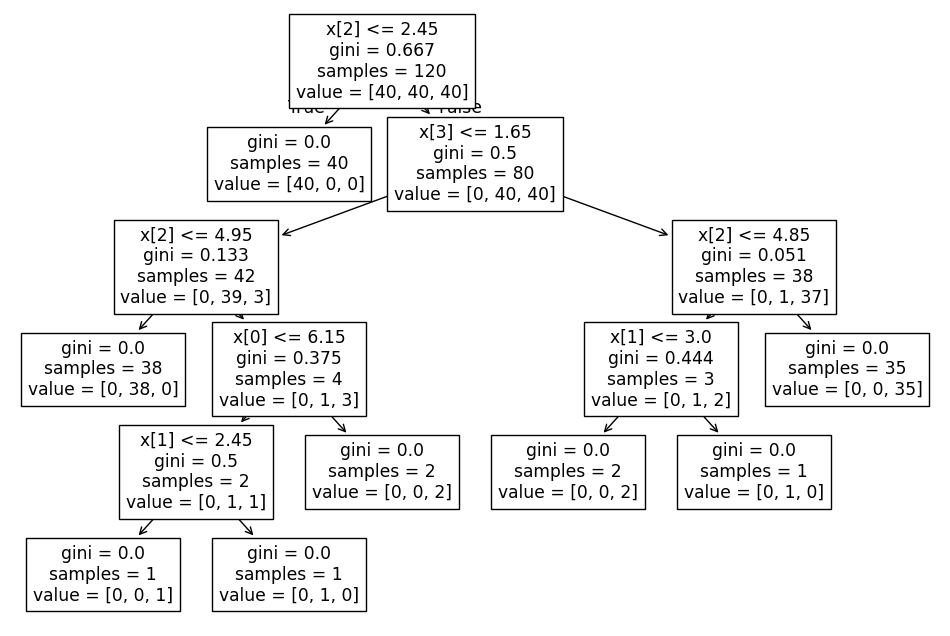

In [6]:

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))

plot_tree(model)

plt.show()

**Adicione seu texto de solução aqui**.

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [1,2,3,4,5,6,7,8,9,None]

resultados = []

for d in depths:
    
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    profundidade = model.get_depth()
    folhas = model.get_n_leaves()
    
    resultados.append([
        d,
        train_acc,
        test_acc,
        profundidade,
        folhas
    ])

tabela = pd.DataFrame(resultados, columns=[
    "max_depth",
    "acuracia_treino",
    "acuracia_teste",
    "profundidade_arvore",
    "numero_folhas"
])

print(tabela)

   max_depth  acuracia_treino  acuracia_teste  profundidade_arvore  \
0        1.0         0.666667        0.666667                    1   
1        2.0         0.966667        0.933333                    2   
2        3.0         0.983333        0.966667                    3   
3        4.0         0.991667        0.933333                    4   
4        5.0         1.000000        0.933333                    5   
5        6.0         1.000000        0.933333                    5   
6        7.0         1.000000        0.933333                    5   
7        8.0         1.000000        0.933333                    5   
8        9.0         1.000000        0.933333                    5   
9        NaN         1.000000        0.933333                    5   

   numero_folhas  
0              2  
1              3  
2              5  
3              7  
4              8  
5              8  
6              8  
7              8  
8              8  
9              8  


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

criterios = ["gini", "entropy"]

resultados = []

for c in criterios:
    
    model = DecisionTreeClassifier(criterion=c, random_state=42)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    profundidade = model.get_depth()
    
    resultados.append([
        c,
        profundidade,
        train_acc,
        test_acc
    ])

tabela = pd.DataFrame(resultados, columns=[
    "criterion",
    "profundidade",
    "acuracia_treino",
    "acuracia_teste"
])

print(tabela)

  criterion  profundidade  acuracia_treino  acuracia_teste
0      gini             5              1.0        0.933333
1   entropy             5              1.0        0.933333


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [1,2,3,4,5,6,7,8,9,None]

resultados = []

for d in depths:

    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    resultados.append([d, train_acc, test_acc])

tabela = pd.DataFrame(resultados, columns=[
    "max_depth",
    "acuracia_treino",
    "acuracia_teste"
])

print(tabela)

   max_depth  acuracia_treino  acuracia_teste
0        1.0         0.666667        0.666667
1        2.0         0.966667        0.933333
2        3.0         0.983333        0.966667
3        4.0         0.991667        0.933333
4        5.0         1.000000        0.933333
5        6.0         1.000000        0.933333
6        7.0         1.000000        0.933333
7        8.0         1.000000        0.933333
8        9.0         1.000000        0.933333
9        NaN         1.000000        0.933333
